# Exploratory Data Analysis — UNSW-NB15 Intrusion Detection Dataset

This notebook explores the UNSW-NB15 training and testing sets to understand what kind of network traffic we're working with before building any detection model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path.cwd().parent / "data"
TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (82332, 45)
Testing set shape: (175341, 45)


## Summary statistics

`.describe()` gives us the min, max, mean, and spread of every numeric field. For a security analyst, this is a sanity check: it flags fields with extreme outliers (e.g. a `dur` or `sbytes` value thousands of times larger than the rest), which often correspond to unusual — potentially malicious — sessions rather than data errors.

In [2]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,82332.0,4.116650e+04,2.376735e+04,1.0,20583.750000,4.116650e+04,6.174925e+04,8.233200e+04
dur,82332.0,1.006756e+00,4.710444e+00,0.0,0.000008,1.413800e-02,7.193603e-01,5.999999e+01
spkts,82332.0,1.866647e+01,1.339164e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04
dpkts,82332.0,1.754594e+01,1.155741e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000000,5.340000e+02,1.280000e+03,1.435577e+07
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000000,1.780000e+02,9.560000e+02,1.465753e+07
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606114,2.650177e+03,1.111111e+05,1.000000e+06
sttl,82332.0,1.809677e+02,1.015134e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,82332.0,9.571300e+01,1.166677e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.466797,5.770032e+05,6.514286e+07,5.268000e+09


## Data types and null values

Before feeding this into a model, we need to know which columns are numeric vs categorical (text), and whether any values are missing. Missing values in security telemetry usually mean a sensor failed to capture a field, not that "nothing happened" — so they need explicit handling rather than being silently dropped.

In [3]:
dtypes_nulls = pd.DataFrame({
    "dtype": train_df.dtypes,
    "null_count": train_df.isnull().sum(),
})
dtypes_nulls

,dtype,null_count
id,int64,0
dur,float64,0
proto,str,0
service,str,0
state,str,0
spkts,int64,0
dpkts,int64,0
sbytes,int64,0
dbytes,int64,0
rate,float64,0


## Class balance: normal vs attack traffic

The `label` column is our ground truth: `0` = normal traffic, `1` = an attack of some kind. This chart tells an analyst how skewed the dataset is. If attacks vastly outnumber (or are vastly outnumbered by) normal traffic, a model trained on it can get a misleadingly high accuracy just by always guessing the majority class — so this balance directly informs how we should evaluate any detector (e.g. using precision/recall instead of raw accuracy).

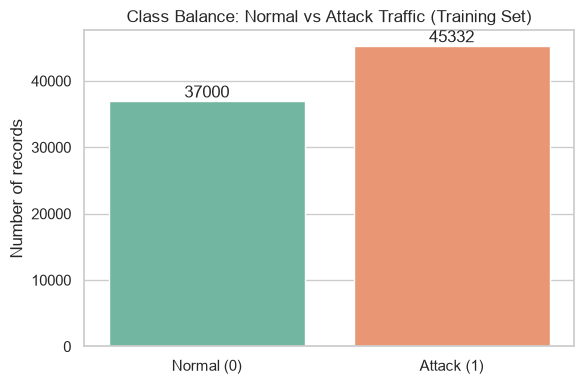

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train_df["label"].value_counts().sort_index()
labels = ["Normal (0)", "Attack (1)"]
sns.barplot(x=labels, y=counts.values, hue=labels, palette="Set2", legend=False, ax=ax)
ax.set_title("Class Balance: Normal vs Attack Traffic (Training Set)")
ax.set_ylabel("Number of records")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, str(v), ha="center")
plt.tight_layout()
plt.show()

## Attack type distribution

`attack_cat` breaks the `1`s in `label` down into specific attack families (Generic, Exploits, DoS, etc.), plus `Normal` for the `0`s. This tells an analyst *what kind* of malicious activity dominates the traffic. A dataset dominated by `Generic` or `Exploits` attacks trains a model to be good at catching those, but rare categories like `Worms` will be hard for any model to learn reliably simply because there are so few examples — a real-world detector built on this data would need extra attention (or additional data) for those rare-but-dangerous attack types.

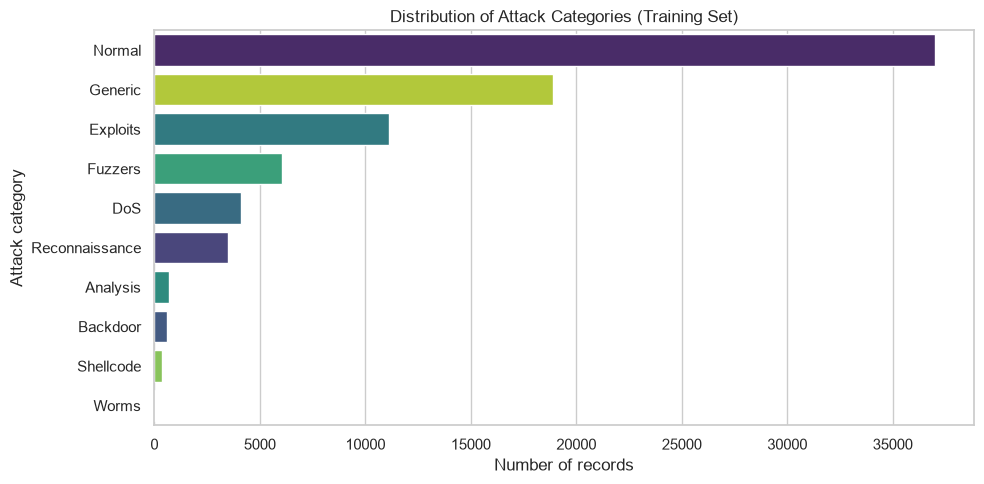

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
order = train_df["attack_cat"].value_counts().index
sns.countplot(data=train_df, y="attack_cat", order=order, hue="attack_cat", palette="viridis", legend=False, ax=ax)
ax.set_title("Distribution of Attack Categories (Training Set)")
ax.set_xlabel("Number of records")
ax.set_ylabel("Attack category")
plt.tight_layout()
plt.show()

## Correlation heatmap of numeric features

This heatmap shows how strongly each numeric traffic feature (packet counts, byte counts, timing, TTL, etc.) moves together with the others. For an analyst, strongly correlated pairs (dark red/blue) suggest redundant signals — e.g. if `sbytes` and `spkts` always rise together, you may only need one of them to describe "how much data was sent." This also helps a data scientist decide which features to drop or combine before training, since highly redundant features can bias a model without adding real detection power.

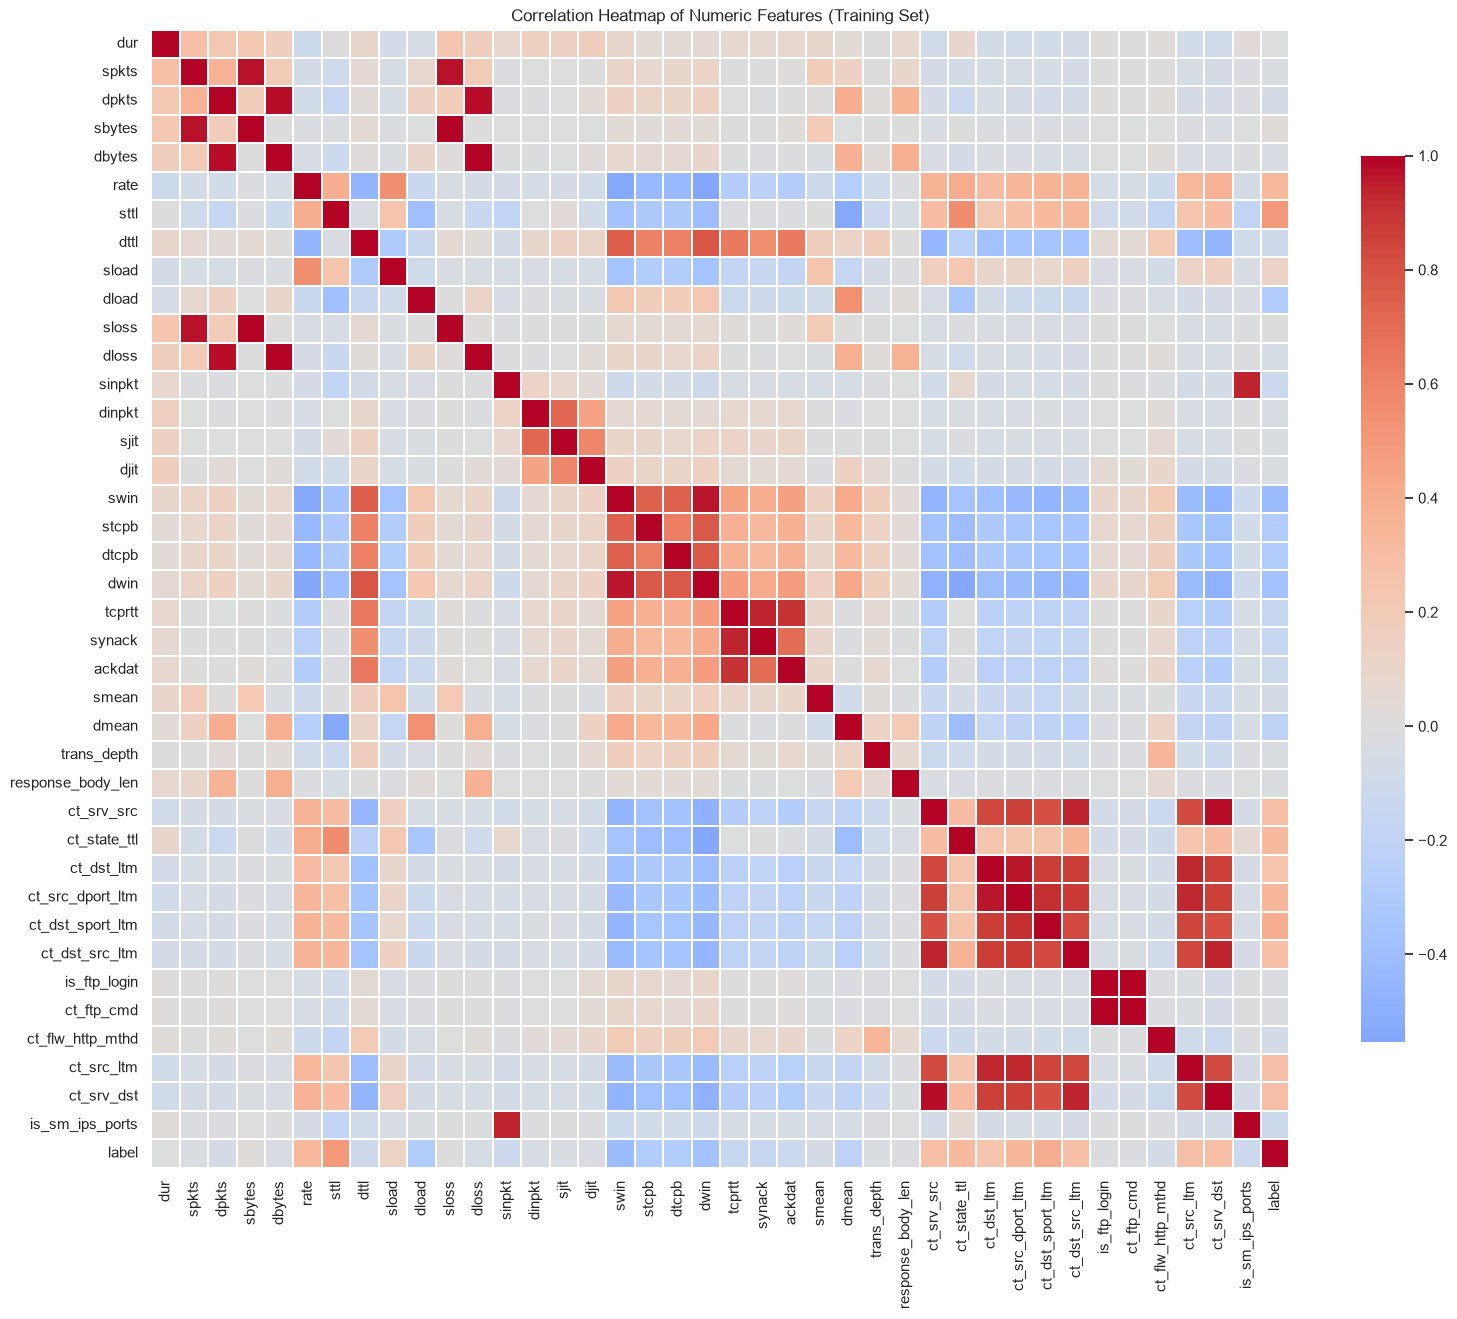

In [6]:
numeric_df = train_df.select_dtypes(include=[np.number]).drop(columns=["id"], errors="ignore")
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features (Training Set)")
plt.tight_layout()
plt.show()

## Takeaways

- The training set is attack-heavy (more attacks than normal traffic), while the testing set is even more so — any model evaluation should look beyond plain accuracy.
- `Generic` and `Exploits` are the dominant attack types; `Worms`, `Shellcode`, and `Backdoor` are rare, so detecting them reliably will be the hardest part of this problem.
- Several numeric features are highly correlated, which is useful to know before feature selection or dimensionality reduction in a later modeling step.